# Reasoning as an intervention: agreement with reasoning off vs. on


Run from the repository root or from `notebooks/`. The values are computed from the aggregated
results in `results/*-aggregated-0-bullet-is.csv` and the per-run predictions under
`$REASONANCE_RESULTS_ROOT`, and cached in `results/pair-values/` (`refresh=True` recomputes).
Figures are only shown here (`save=False`); pass `save=True` to write them to
`results/figures/paper/`.

Paper figures in this notebook:

- main text: `fig:agree-effort`, `fig:effort-recourse`
- appendix: `fig:appendix-effort-kappa-components-all-tasks`,
  `fig:appendix-effort-kappa-by-level-all-tasks`,
  `fig:appendix-effort-pairwise-agreement-by-correctness-all-tasks`,
  `fig:appendix-effort-recourse-distribution`, `fig:appendix-effort-recourse-by-label-all-tasks`,
  `fig:appendix-effort-recourse-transitions-all-tasks`

In [ ]:
import os
from pathlib import Path

# every path in `reasonance` is relative to the repository root
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import matplotlib.pyplot as plt
from reasonance.analysis import (
    effort_pairs_for_tasks,
)
from reasonance.paper_figures import (
    effort_components,
    effort_levels,
    effort_main,
    effort_outcome_split,
    effort_vote_by_label,
    effort_vote_main,
    effort_vote_movement,
    effort_vote_observed,
)
from reasonance.plotting import set_figure_prefix, set_plot_style

QA_MODE = "numeric"
set_plot_style()
set_figure_prefix(QA_MODE)  # the tasks are panels, so only the QA mode is in the file name

('numeric',)

## Pairwise agreement per matched model pair

Accuracy-adjusted agreement (the paper metric) for every pair of matched models, with reasoning off
and on. Recomputed every time, so a cached value from before the last aggregate rebuild never
reaches a figure.

In [2]:
pairs = effort_pairs_for_tasks(refresh=True)

## Agreement with reasoning off vs. on

Paper: `fig:agree-effort`.

One panel per task.

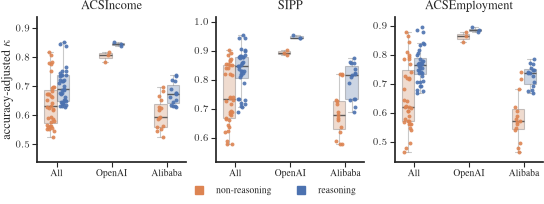

In [3]:
effort_main(data=pairs, save=False)
plt.show()

## Kappa components

Paper: `fig:appendix-effort-kappa-components-all-tasks`.

The metric taken apart: observed agreement, baseline agreement, their difference, and kappa. One
line per model pair, colored by developer.

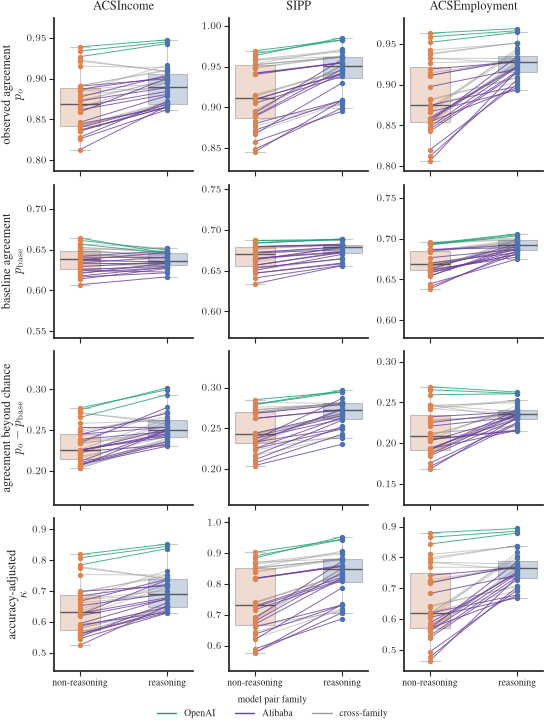

In [4]:
effort_components(data=pairs, save=False)
plt.show()

## Agreement between runs at the same effort level

Paper: `fig:appendix-effort-kappa-by-level-all-tasks`.

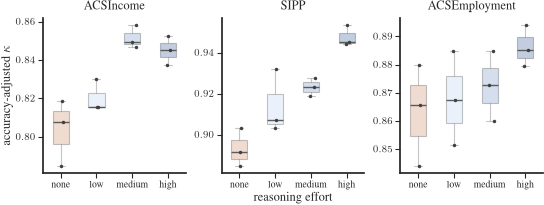

In [5]:
effort_levels(save=False)
plt.show()

## Agreement split by outcome

Paper: `fig:appendix-effort-pairwise-agreement-by-correctness-all-tasks`.

`p_o = agree_correct + agree_wrong`: the bottom row is the share of individuals who receive the
same wrong decision from both models. One line per model pair. Descriptive only -- for a PAIR the
excess over the independent-models null is equal at both ends by construction, so the clustering
question needs three or more models (below).

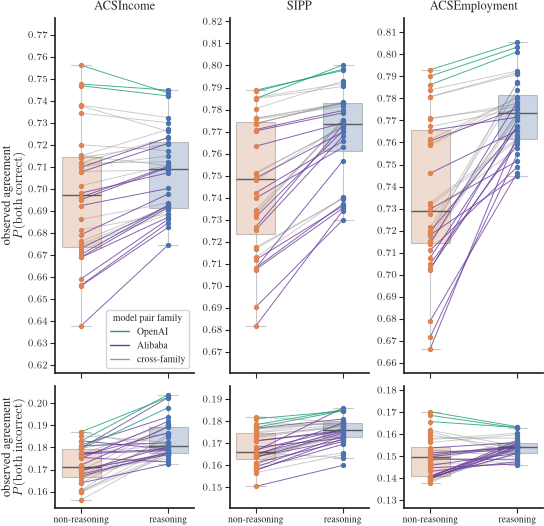

In [6]:
effort_outcome_split(save=False)
plt.show()

## Excess over independent errors, reasoning off and on

Paper: `fig:effort-recourse`.

Per individual, the number of correct predictions among the nine matched models; the bars are the
excess of that distribution over independent errors at each model's own accuracy, so zero means
"accuracy alone explains this". Nine models is what makes the shape informative -- at N=2 the excess
at "all wrong" and "all correct" is equal by construction.

Seeds: a vote count is a number of models, so each distribution takes one run per matched model --
and every seed still enters, as seed draws (draw r = every model's r-th seed), averaged over the
draws. The same construction as the vote figures of the length notebook.

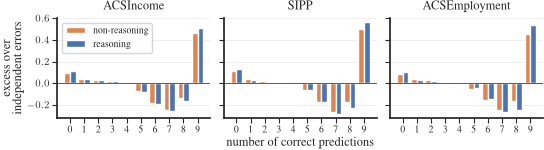

In [7]:
effort_vote_main(refresh=True, save=False)
plt.show()

## The vote distribution behind the excess

Paper: `fig:appendix-effort-recourse-distribution`.

The observed distribution the excess is taken from: the share of individuals at each number of
correct predictions, reasoning off and on, averaged over the same seed draws.

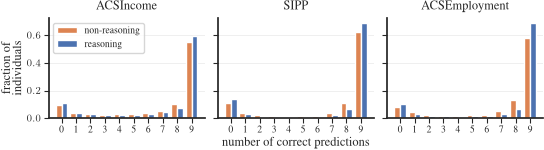

In [8]:
effort_vote_observed(refresh=True, save=False)
plt.show()

## The excess within each true label

Paper: `fig:appendix-effort-recourse-by-label-all-tasks`.

Checks whether the unanimity beyond accuracy is carried by one class.

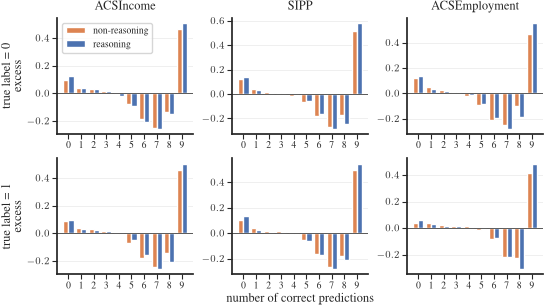

In [9]:
effort_vote_by_label(refresh=True, save=False)
plt.show()

## Movement on the unanimity ladder

Paper: `fig:appendix-effort-recourse-transitions-all-tasks`.

The vote figure compares two distributions; this one follows the individuals between them. Top
row: an individual's number of correct predictions from the matched models with reasoning off (x)
and on (y), the diagonal blanked because it is the unmoved mass. Bottom row: one step per
individual, stacked by the consensus level they end at.

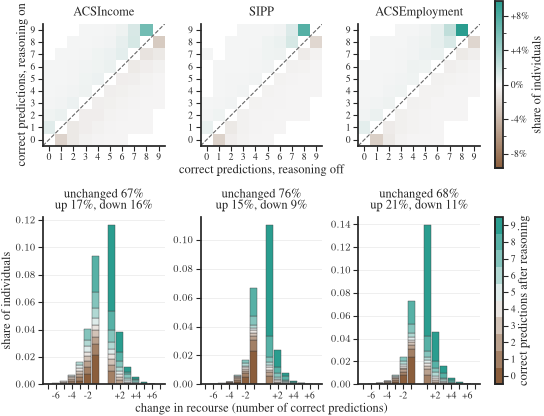

In [10]:
effort_vote_movement(refresh=True, save=False)
plt.show()